In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [17]:
df = pd.read_csv("../data/preprocessed/fakenews_preprocessed.csv")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62126 entries, 0 to 62125
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  62126 non-null  str    
 1   text                   62126 non-null  str    
 2   subject                62126 non-null  str    
 3   real                   62126 non-null  int64  
 4   clean_title            62126 non-null  str    
 5   clean_text             62126 non-null  str    
 6   text_len               62126 non-null  int64  
 7   avg_word_len           61679 non-null  float64
 8   num_sents              62126 non-null  int64  
 9   polarity               62126 non-null  float64
 10  subjectivity           62126 non-null  float64
 11  prep_text              61678 non-null  str    
 12  word_count             62126 non-null  int64  
 13  unique_words           62126 non-null  int64  
 14  lexical_richness       62126 non-null  float64
 15  sentence_coun

In [19]:
df.head()

,title,text,subject,real,clean_title,clean_text,text_len,avg_word_len,num_sents,polarity,...,flesch_ease,flesch_grade,gunning_fog,smog,ari,coleman_liau,flesch_interpretation,punct_count,punct_ratio,entity_count
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,donald trump sends out embarrassing new ear s...,donald trump just couldn t wish all americans ...,503,4.337972,1,-0.014387,...,62.715000,8.726552,10.363443,11.812371,9.679789,9.062195,Standard - 8th-9th grade,121,0.244444,28
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,drunk bragging trump staffer started russian ...,house intelligence committee chairman devin nu...,309,4.951456,1,0.033536,...,46.787209,10.942923,13.072860,12.745085,11.595993,11.947541,Difficult - College,39,0.127869,24
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,sheriff david clarke becomes an internet joke...,on frida it was revealed that former milwaukee...,598,4.658863,1,-0.020018,...,61.930106,8.616870,10.647496,11.645159,10.957494,10.928843,Standard - 8th-9th grade,148,0.255172,37
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,trump is so obsessed he even has obama s name...,on christmas da donald trump announced that he...,458,4.665939,1,-0.026923,...,55.028359,9.966244,12.498177,13.023867,11.788649,11.285261,Fairly Difficult - 10th-12th grade,118,0.265766,26
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,pope francis just called out donald trump dur...,pope francis used his annual christmas da mess...,425,4.322353,1,-0.069810,...,62.447143,9.766190,12.209524,11.505630,10.522929,8.655714,Standard - 8th-9th grade,40,0.095238,24


In [20]:
df = df.dropna(subset=["prep_text"]).reset_index(drop=True)

In [21]:
df.duplicated(subset="prep_text").sum()

np.int64(9015)

In [22]:
import re

def clean_text(t):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"[^\w\s]", "", t)
    return t.strip()

df["text_clean"] = df["prep_text"].apply(clean_text)
df = df.drop_duplicates(subset="text_clean")

In [23]:
df = df.drop_duplicates(subset="text").reset_index(drop=True)

In [24]:
df = df.sort_values(by="text_clean")

# vectorize smaller chunks
vectorizer = TfidfVectorizer(stop_words='english', max_features=30000)

to_remove = set()
chunk_size = 2000

for start in range(0, len(df), chunk_size):
    end = min(start + chunk_size, len(df))
    chunk = df.iloc[start:end]

    X_chunk = vectorizer.fit_transform(chunk["text_clean"])
    sim = cosine_similarity(X_chunk)

    for i in range(sim.shape[0]):
        for j in range(i+1, sim.shape[0]):
            if sim[i, j] > 0.95:
                to_remove.add(chunk.index[j])

df = df.drop(list(to_remove)).reset_index(drop=True)

In [25]:
df.duplicated(subset="prep_text").sum()

np.int64(0)

In [26]:
X = df["prep_text"].to_numpy(dtype=str)
y = df["real"].to_numpy(dtype=int)

In [27]:
X.shape

(51860,)

In [28]:
y.shape

(51860,)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1": f1_score(y_true, y_pred, average='macro')
    }

In [31]:
results = []

# TF-IDF

In [32]:
tfidf = TfidfVectorizer(binary=True)

In [33]:
X_train = tfidf.fit_transform(X_train)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6514253 stored elements and shape (41488, 165692)>

In [34]:
X_val = tfidf.transform(X_val)
X_val

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1612160 stored elements and shape (10372, 165692)>

# Logistic Regression

In [35]:
model_lr = LogisticRegression(max_iter=2000, random_state=42)

In [36]:
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_pred = model_lr.predict(X_val)

In [38]:
metrics_lr = evaluate_model("Logistic Regression", y_val, y_pred)
metrics_lr

{'Model': 'Logistic Regression',
 'Accuracy': 0.9836097184728114,
 'Precision': 0.9855511544850273,
 'Recall': 0.9777413458656,
 'F1': 0.9814899038072111}

In [39]:
results.append(metrics_lr)

# Ridge Regression

In [40]:
model_rr = RidgeClassifier()

In [41]:
model_rr.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",None


In [42]:
y_pred_rr = model_rr.predict(X_val)

In [43]:
metrics_rr = evaluate_model("Ridge Classifier", y_val, y_pred_rr)
metrics_rr

{'Model': 'Ridge Classifier',
 'Accuracy': 0.9889124566139607,
 'Precision': 0.99092809141922,
 'Recall': 0.9842844678577386,
 'F1': 0.9874940938536394}

In [44]:
results.append(metrics_rr)

# Random Forest Classifier

In [45]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [46]:
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
y_pred_rf = model_rf.predict(X_val)

In [48]:
metrics_rf = evaluate_model("Random Forest Classifier", y_val, y_pred_rf)
metrics_rf

{'Model': 'Random Forest Classifier',
 'Accuracy': 0.966737369841882,
 'Precision': 0.9746283308686945,
 'Recall': 0.9516494674603146,
 'F1': 0.9618481381384119}

In [49]:
results.append(metrics_rf)

# Gradient Boosting

In [50]:
model_gbc = GradientBoostingClassifier(random_state=42)

In [51]:
model_gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [52]:
y_pred_gbc = model_gbc.predict(X_val)

In [53]:
metrics_gbc = evaluate_model("Gradient Boosting Classifier", y_val, y_pred_gbc)
metrics_gbc

{'Model': 'Gradient Boosting Classifier',
 'Accuracy': 0.9627844195912071,
 'Precision': 0.9602237112542303,
 'Recall': 0.9561084885577745,
 'F1': 0.9581183296590732}

In [54]:
results.append(metrics_gbc)

# XGBoost

In [55]:
model_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    tree_method="hist"
)

In [56]:
model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [57]:
y_pred_xgb = model_xgb.predict(X_val)

In [58]:
metrics_xgb = evaluate_model("XGBoost Classifier", y_val, y_pred_xgb)
metrics_xgb

{'Model': 'XGBoost Classifier',
 'Accuracy': 0.9852487466255303,
 'Precision': 0.9858013570159598,
 'Recall': 0.9811003276205941,
 'F1': 0.9833932156282195}

In [59]:
results.append(metrics_xgb)

# Visualize the results

In [60]:
df_results = pd.DataFrame(results)

In [61]:
df_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.983610,0.985551,0.977741,0.981490
1,Ridge Classifier,0.988912,0.990928,0.984284,0.987494
2,Random Forest Classifier,0.966737,0.974628,0.951649,0.961848
3,Gradient Boosting Classifier,0.962784,0.960224,0.956108,0.958118
4,XGBoost Classifier,0.985249,0.985801,0.981100,0.983393


In [62]:
from sklearn.utils import shuffle
X_shuf, y_shuf = shuffle(X_train, y_train, random_state=42)

model_lr.fit(X_shuf, y_shuf)
model_lr.score(X_val, y_val)

0.9836097184728114

In [63]:
def predict_news(text, vectorizer, model):
    # Clean the text the same way you preprocessed your dataset
    text_clean = text.lower().strip()

    # Vectorize
    text_tfidf = vectorizer.transform([text_clean])

    # Predict class
    pred = model.predict(text_tfidf)[0]

    # Get probability (if supported)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(text_tfidf)[0]
        return pred, proba
    else:
        return pred, None


In [64]:
text = """
Margaret Brennan and John Dickerson of CBS News claimed that “the president of the United States has nothing to do with the price of bacon,” “or eggs,” “or gas,” “or any of it.”

In fact, presidents impact the prices of virtually everything through federal deficits that spur inflation, regulations that prohibit the use of cost-effective production methods and resources, price and wage controls, trade deals, tariffs, and more.
"""

text2 = """
Reporting on the first assassination attempt against Donald Trump, George Stephanopoulos and Martha Raddatz of ABC News claimed that Trump “contributed” to “violent rhetoric” because he said “it’s going to be a bloodbath” if “I don’t get elected.”

In fact, Trump didn’t use the term “bloodbath” as a call to violence but to describe the effects of Biden’s policies, especially on the auto industry.
"""


text3 = """
MSNBC’s Lawrence O’Donnell claimed that “no one in our lifetimes has saved more lives” than Anthony Fauci.

In fact, Fauci may have killed more people than anyone in our lifetimes:

First, Fauci led the federal agency that funded gain-of-function research on bat coronaviruses at the Wuhan Institute of Virology and then lied about it to Congress.
Second, Fauci greatly overstated the Covid-19 death rate, prompting mass hysteria and lockdowns that already have or ultimately will shorten the lives of millions of people.
Third, Fauci spread the hoax that C-19 was a “pandemic of the unvaccinated” when more than half of all Covid deaths were among the fully vaccinated.
"""

pred, proba = predict_news(text, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)


Prediction: FAKE
Probabilities: [0.80017023 0.19982977]


In [65]:
pred, proba = predict_news(text2, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)

Prediction: FAKE
Probabilities: [0.89837265 0.10162735]


In [66]:
pred, proba = predict_news(text3, tfidf, model_lr)

print("Prediction:", "REAL" if pred == 1 else "FAKE")

if proba is not None:
    print("Probabilities:", proba)

Prediction: FAKE
Probabilities: [0.71876607 0.28123393]


In [67]:
df_melt = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

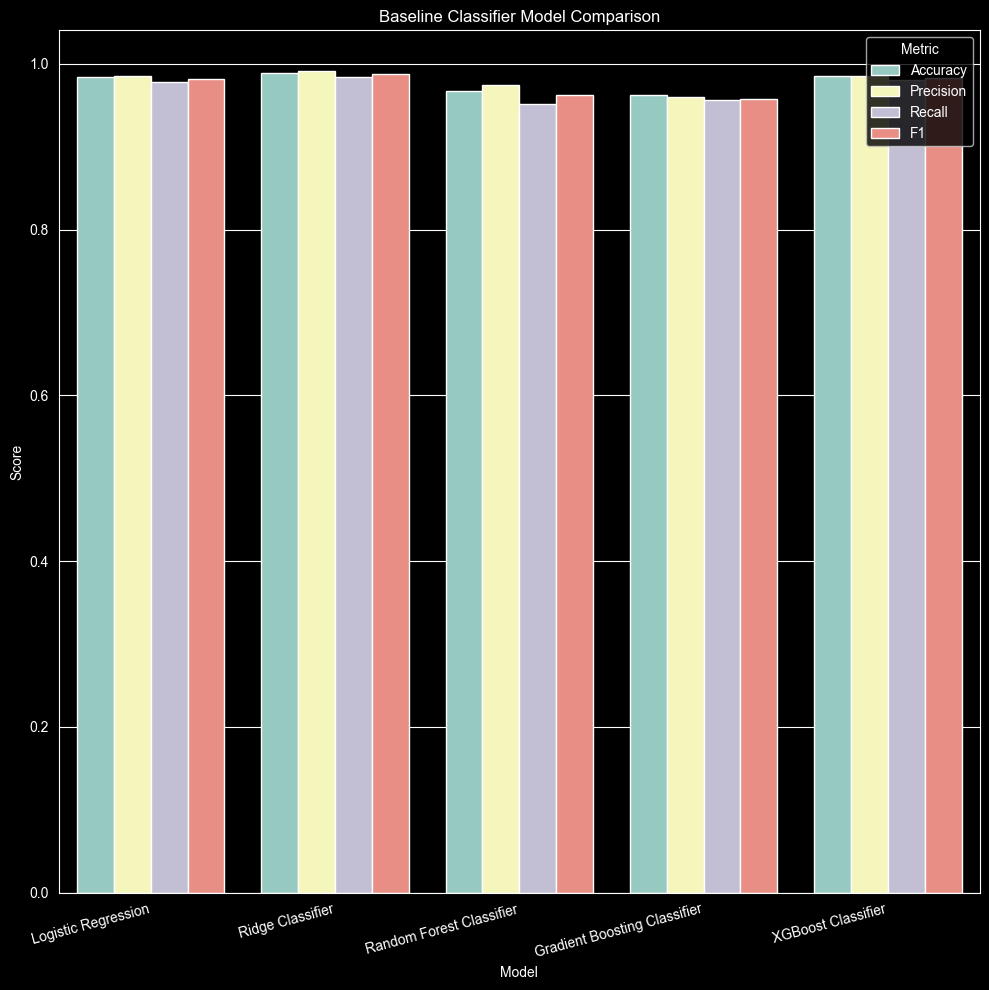

In [68]:
plt.figure(figsize = (10,10))
sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")
plt.title("Baseline Classifier Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../images/classicModels.png")
plt.show()

In [69]:
from sklearn.metrics import confusion_matrix, classification_report

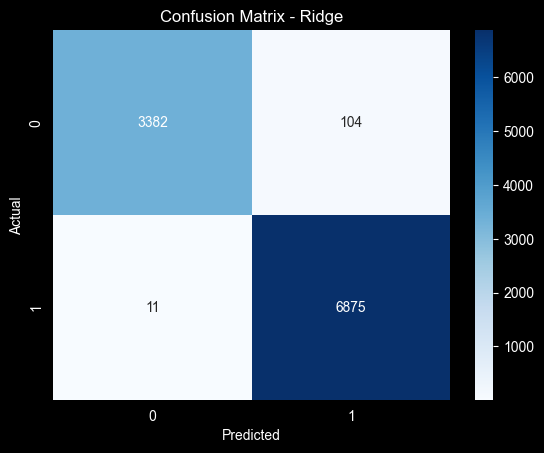


Ridge:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98      3486
           1       0.99      1.00      0.99      6886

    accuracy                           0.99     10372
   macro avg       0.99      0.98      0.99     10372
weighted avg       0.99      0.99      0.99     10372



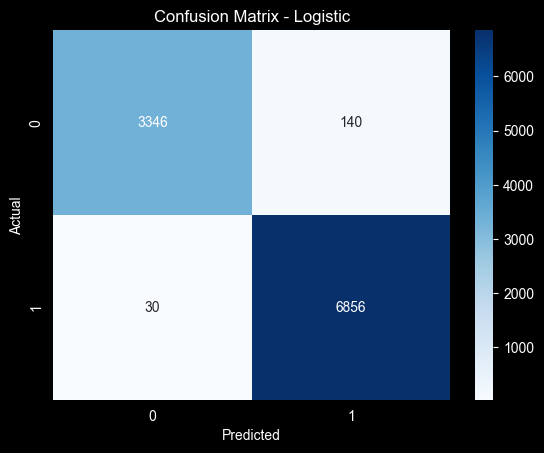


Logistic:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      3486
           1       0.98      1.00      0.99      6886

    accuracy                           0.98     10372
   macro avg       0.99      0.98      0.98     10372
weighted avg       0.98      0.98      0.98     10372



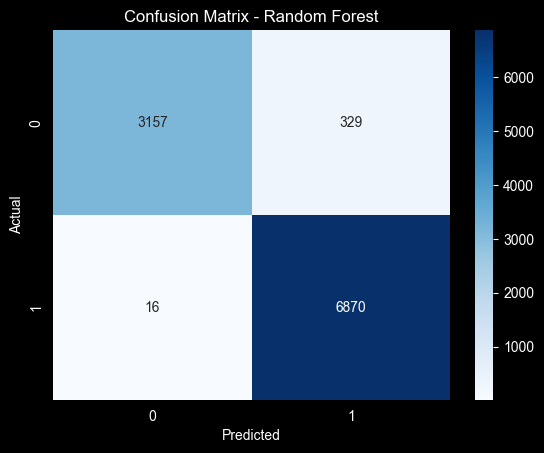


Random Forest:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      3486
           1       0.95      1.00      0.98      6886

    accuracy                           0.97     10372
   macro avg       0.97      0.95      0.96     10372
weighted avg       0.97      0.97      0.97     10372



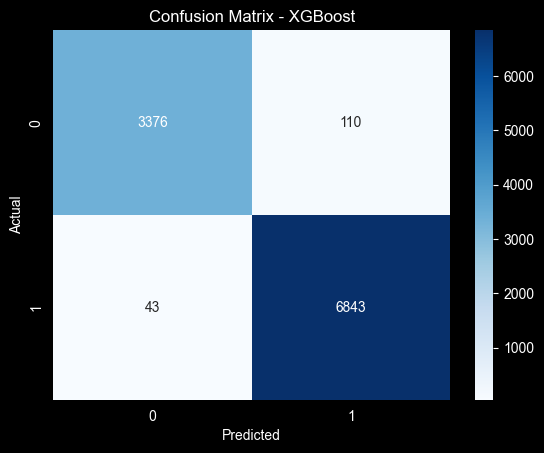


XGBoost:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3486
           1       0.98      0.99      0.99      6886

    accuracy                           0.99     10372
   macro avg       0.99      0.98      0.98     10372
weighted avg       0.99      0.99      0.99     10372



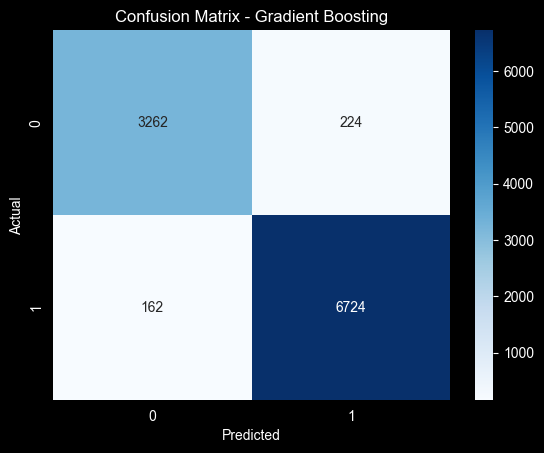


Gradient Boosting:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      3486
           1       0.97      0.98      0.97      6886

    accuracy                           0.96     10372
   macro avg       0.96      0.96      0.96     10372
weighted avg       0.96      0.96      0.96     10372



In [70]:
for name, model in [("Ridge", model_rr), ("Logistic", model_lr), ("Random Forest", model_rf), ("XGBoost", model_xgb), ("Gradient Boosting", model_gbc) ]:
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\n{name}:\n", classification_report(y_val, y_pred))

In [71]:
df["real"].value_counts(normalize=True)

real
1    0.663922
0    0.336078
Name: proportion, dtype: float64

In [72]:
from sklearn.model_selection import cross_val_score

In [73]:
cv_scores = cross_val_score(model_rr, X_train, y_train, cv=10, scoring="accuracy")

In [74]:
print(cv_scores, cv_scores.mean())

[0.99373343 0.99349241 0.99252832 0.98987708 0.99156423 0.99252832
 0.99252832 0.99156423 0.99059788 0.9915622 ] 0.991997641843267


In [75]:
from sklearn.model_selection import cross_validate

In [76]:
scoring = {
    "f1_fake": "f1_macro",
    "f1_weighted": "f1_weighted"
}

In [77]:
scores = cross_validate(model_rr, X_train, y_train, cv=5, scoring=scoring)

In [78]:
print(scores)
print(cv_scores, cv_scores.mean())

{'fit_time': array([0.76257873, 0.7210238 , 0.70948195, 0.71511483, 0.70515084]), 'score_time': array([0.00500488, 0.00450921, 0.00400019, 0.00400257, 0.00400758]), 'test_f1_fake': array([0.99200614, 0.99023508, 0.9910407 , 0.99009617, 0.98981558]), 'test_f1_weighted': array([0.99287736, 0.99130357, 0.99202457, 0.9911813 , 0.99093548])}
[0.99373343 0.99349241 0.99252832 0.98987708 0.99156423 0.99252832
 0.99252832 0.99156423 0.99059788 0.9915622 ] 0.991997641843267


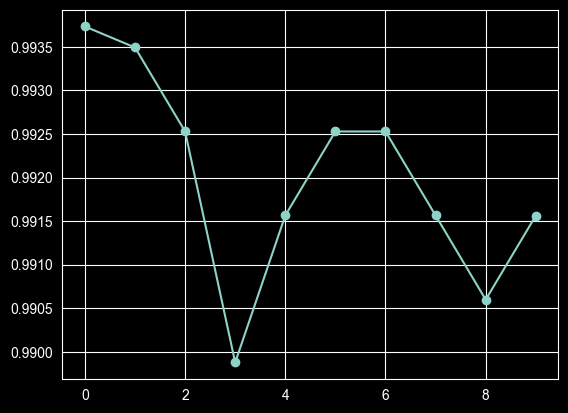

In [79]:
plt.plot(cv_scores, marker="o")

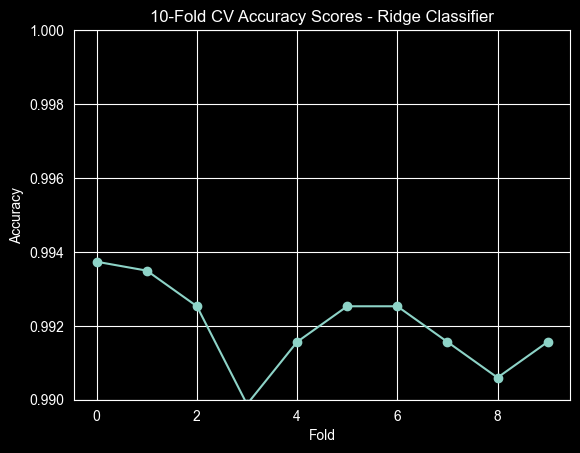

In [80]:
plt.plot(cv_scores, marker='o')
plt.title("10-Fold CV Accuracy Scores - Ridge Classifier")
plt.ylabel("Accuracy")
plt.xlabel("Fold")
plt.ylim(0.99, 1.0)
plt.grid(True)
plt.show()